# 2. Logistic Regression — Churn Prediction
This notebook builds a Logistic Regression classifier to predict customer churn.
It loads the cleaned dataset exported by the EDA notebook and follows a full ML pipeline:

1. Data loading
2. Preprocessing
3. Hyperparameter tuning
4. Evaluation

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import time

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data
We load the cleaned dataset exported by the EDA notebook from `data/processed/`. This dataset has already been cleaned, deduplicated, and stripped of leakage columns. Apart from that, it only contains our final feature selection

In [8]:
df = pd.read_csv('../data/processed/telecom_churn_cleaned.csv')
print(f"Shape: {df.shape}")
df.head(3)


Shape: (7043, 21)


,number of dependents,number of referrals,tenure in months,phone service,avg monthly long distance charges,multiple lines,internet service,internet type,avg monthly gb download,online security,...,device protection plan,premium tech support,unlimited data,contract,paperless billing,payment method,monthly charge,total revenue,churned,age_group
0,0,2,9,1,42.39,0,1,Cable,16.0,0,...,0,1,1,One Year,1,Credit Card,65.6,974.81,0,35-44
1,0,0,9,1,10.69,1,1,Cable,10.0,0,...,0,0,0,Month-to-Month,0,Credit Card,-4.0,610.28,0,45-54
2,0,0,4,1,33.65,0,1,Fiber Optic,30.0,0,...,1,0,1,Month-to-Month,1,Bank Withdrawal,73.9,415.45,1,45-54


In [3]:
import os
os.getcwd()

'c:\\Users\\Techtop\\Desktop\\NOVA\\S2.1\\Machine Learning\\MachineLearning_TelekomChurn\\notebooks'

## 2.1 Train/Test Split
The target variable is `churned` (1 = churned, 0 = retained). We apply a stratified 80/20 split to preserve the class distribution across both sets.


In [9]:
TARGET = "churned"

X = df.drop(columns=[TARGET, "total revenue"])  # total revenue is highly correlated with tenure in months, so 

y = df[TARGET]

binary_features = [
    "phone service", "multiple lines", "internet service",
    "online security", "online backup", "device protection plan",
    "premium tech support", "unlimited data", "paperless billing"
]

numeric_features = [c for c in X.select_dtypes(include=["int64", "float64"]).columns 
                    if c not in binary_features]
categorical_features = list(X.select_dtypes(include=["object", "category"]).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape}  Test size: {X_test.shape}")
print(f"Churn rate train: {y_train.mean():.2%}  Churn rate test: {y_test.mean():.2%}")

Train size: (5634, 19)  Test size: (1409, 19)
Churn rate train: 26.54%  Churn rate test: 26.54%


## 2.2 Preprocessing Pipeline (editing adding all3)
Numeric features are standardized using `StandardScaler` to ensure that differences in scale do not distort the logistic regression coefficients. Categorical features are encoded using `OneHotEncoder` with `drop="first"` to avoid multicollinearity. The full pipeline combines preprocessing and the classifier, ensuring that no data from the test set leaks into the training process.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features),
    ],
    remainder="drop",
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])
hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),  
    ("classifier", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

## 3. Hyperparameter Tuning (editing all 3 hyperparamter tunings)
We use `GridSearchCV` with 5-fold cross-validation to find the optimal regularization strength `C` and penalty type. A lower `C` means stronger regularization (less overfitting), a higher `C` means the model fits more closely to the training data. We optimize for ROC-AUC, which is more informative than accuracy for imbalanced classification problems like churn.

In [11]:
param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],
    "classifier__max_iter": [500, 1000, 2000],
    "classifier__class_weight": ["balanced", {0: 1, 1: 2}, {0: 1, 1: 3}]
}

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

best_model = grid_search.best_estimator_

print(f"\nGrid search completed in {elapsed:.1f} seconds")
print(f"Total fits: {len(grid_search.cv_results_['params']) * 5}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC:      {grid_search.best_score_:.4f}")

param_grid_hgb = {
    "classifier__max_iter": [100, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__min_samples_leaf": [20, 50],
    "classifier__l2_regularization": [0.0, 1.0]
}

grid_search_hgb = GridSearchCV(
    hgb_pipeline,
    param_grid_hgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search_hgb.fit(X_train, y_train)
elapsed = time.time() - start

best_hgb = grid_search_hgb.best_estimator_

print(f"\nGrid search completed in {elapsed:.1f} seconds")
print(f"Total fits: {len(grid_search_hgb.cv_results_['params']) * 5}")
print(f"Best parameters: {grid_search_hgb.best_params_}")
print(f"Best CV AUC:      {grid_search_hgb.best_score_:.4f}")

param_grid_rf = {
    "classifier__n_estimators"     : [100, 200],
    "classifier__max_depth"        : [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features"     : ["sqrt", "log2"],
    "classifier__class_weight"     : ["balanced", None]
}

grid_search_rf = GridSearchCV(
    rf_pipeline, param_grid_rf,
    cv=5, scoring="roc_auc", n_jobs=-1, verbose=1
)

start = time.time()
grid_search_rf.fit(X_train, y_train)
elapsed = time.time() - start

best_rf = grid_search_rf.best_estimator_

print(f"\nGrid search completed in {elapsed:.1f} seconds")
print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV AUC:      {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Grid search completed in 18.8 seconds
Total fits: 540
Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': {0: 1, 1: 2}, 'classifier__max_iter': 500, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV AUC:      0.8840
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Grid search completed in 47.9 seconds
Total fits: 360
Best parameters: {'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__max_iter': 100, 'classifier__min_samples_leaf': 50}
Best CV AUC:      0.9088
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Grid search completed in 49.8 seconds
Best parameters: {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV AUC:      0.8994


## 4.1 Results (top code cell is now the code with all 3)
We evaluate the best model on the held-out test set using four complementary metrics:
- **Classification report**: precision, recall, and F1-score per class
- **Confusion matrix**: visual breakdown of true/false positives and negatives
- **ROC curve**: trade-off between true positive rate and false positive rate at different thresholds
- **Feature coefficients**: which features drive churn predictions most strongly, and in which direction

C:\Users\Techtop\AppData\Local\Temp\ipykernel_24692\2088741191.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


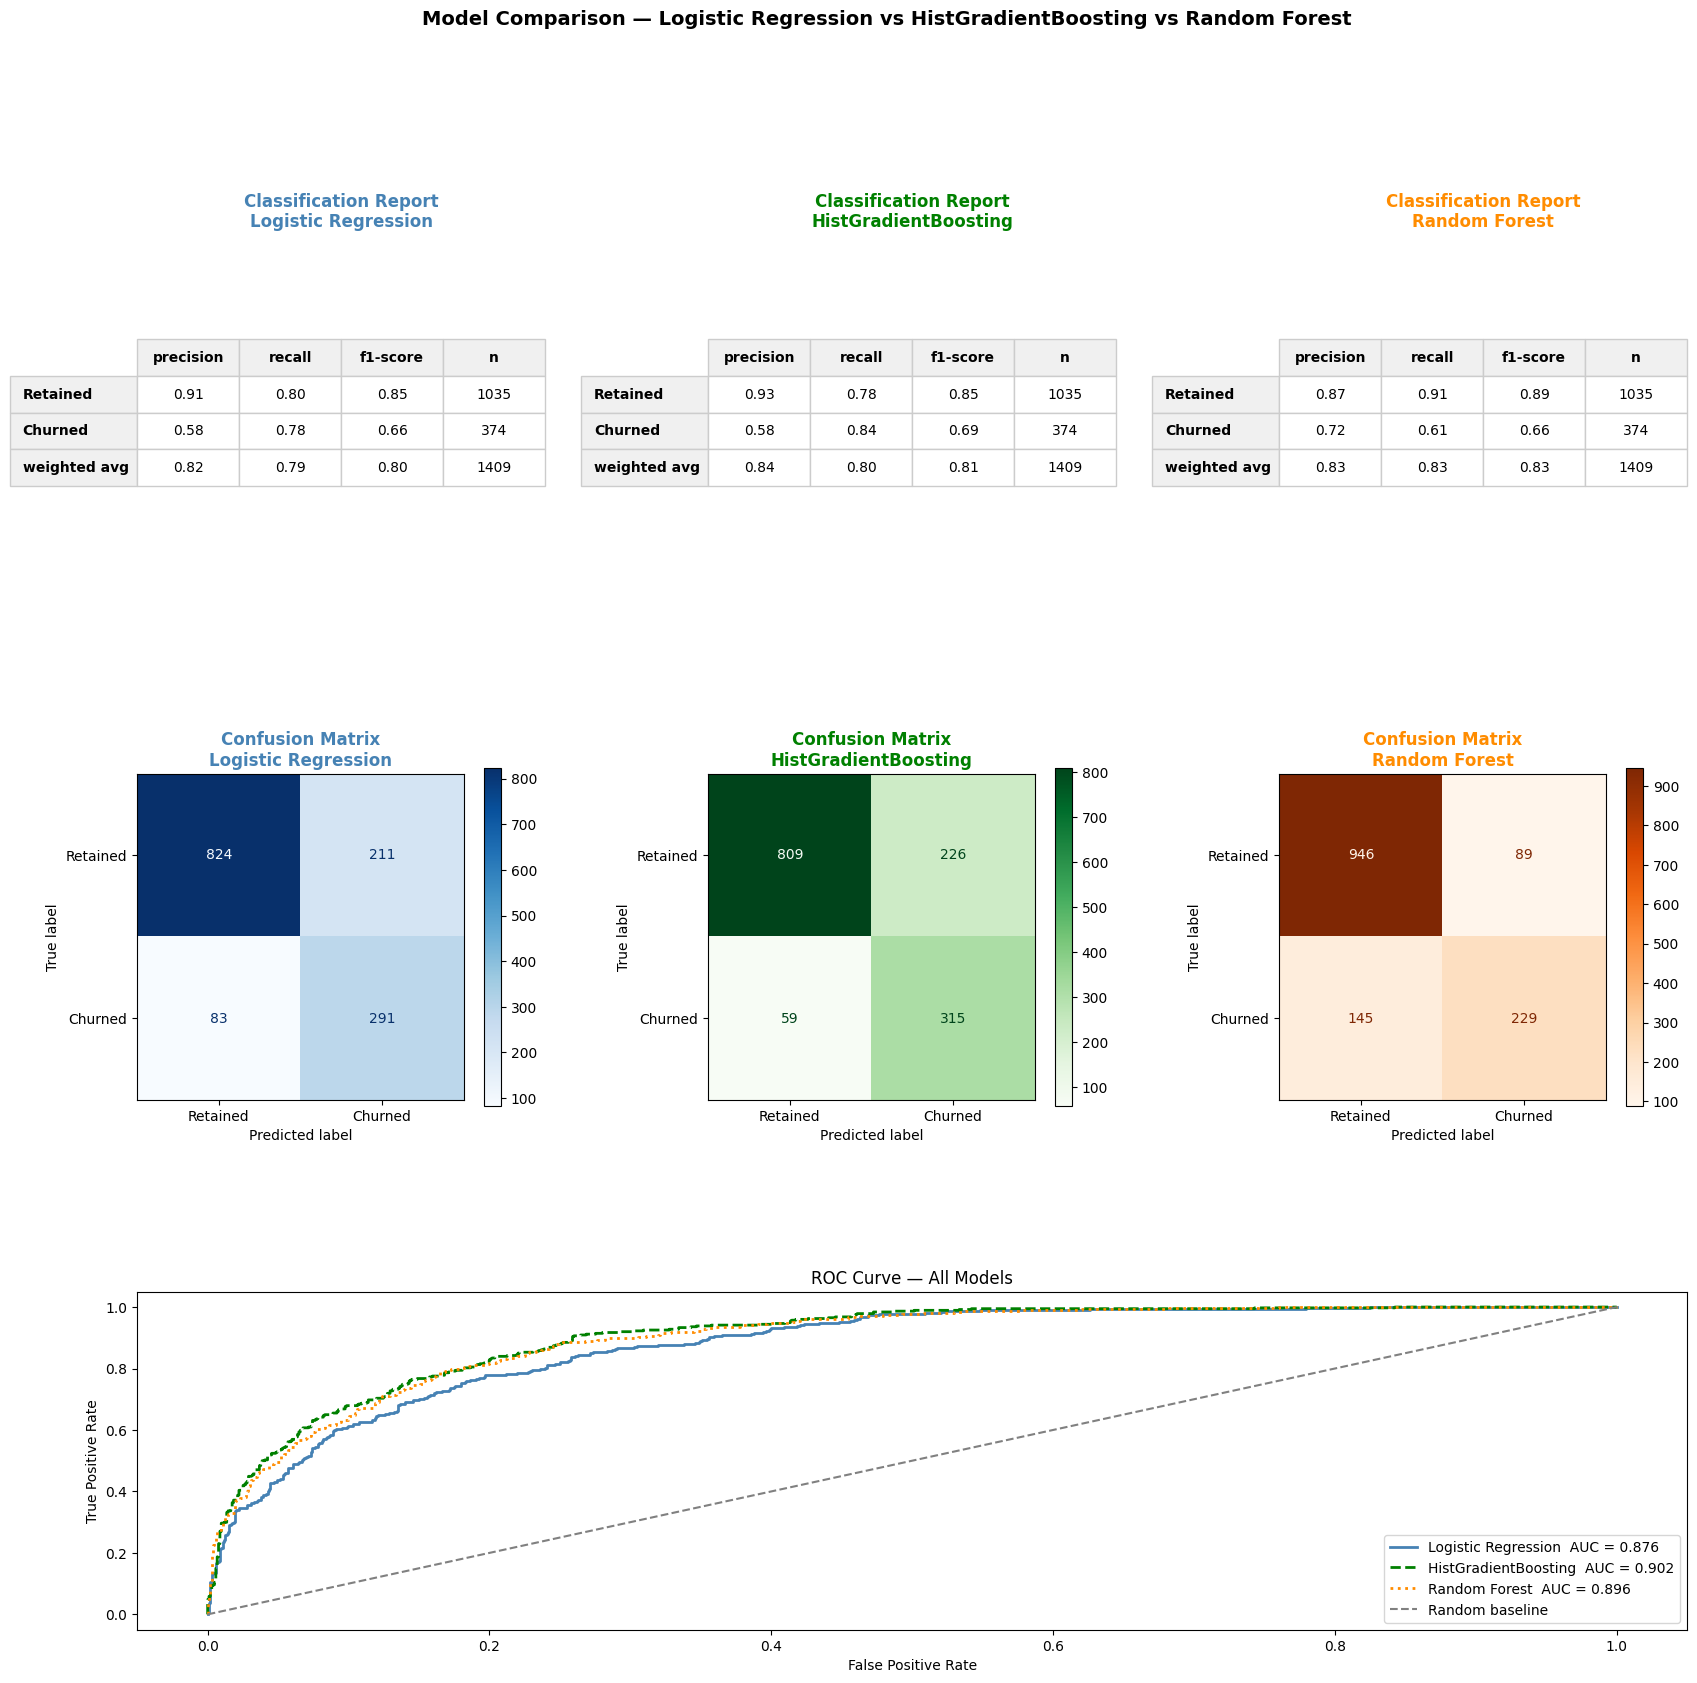

Cross validated AUC (LR):  0.882  ± 0.010
Cross validated AUC (HGB): 0.906 ± 0.007
Cross validated AUC (RF):  0.898  ± 0.009


In [12]:
from matplotlib import gridspec
from sklearn.inspection import permutation_importance

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_rf  = best_rf.predict(X_test);    y_prob_rf  = best_rf.predict_proba(X_test)[:, 1]
y_pred_hgb = best_hgb.predict(X_test);  y_prob_hgb = best_hgb.predict_proba(X_test)[:, 1]
y_pred_lr  = best_model.predict(X_test); y_prob_lr  = best_model.predict_proba(X_test)[:, 1]

# ── Classification reports ────────────────────────────────────────────────────
def make_report(y_pred):
    return (
        pd.DataFrame(classification_report(y_test, y_pred,
                     target_names=["Retained", "Churned"], output_dict=True)).T
        .round(2).rename(columns={"support": "n"})
        .loc[["Retained", "Churned", "weighted avg"]]
    )

report_lr  = make_report(y_pred_lr)
report_hgb = make_report(y_pred_hgb)
report_rf  = make_report(y_pred_rf)
for r in [report_lr, report_hgb, report_rf]:
    r["n"] = r["n"].astype(int)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

models  = ["Logistic Regression", "HistGradientBoosting", "Random Forest"]
reports = [report_lr, report_hgb, report_rf]
y_preds = [y_pred_lr, y_pred_hgb, y_pred_rf]
y_probs = [y_prob_lr, y_prob_hgb, y_prob_rf]
colors  = ["steelblue", "green", "darkorange"]
cmaps   = ["Blues", "Greens", "Oranges"]

# Row 0 — Classification reports
for i, (report, model, col) in enumerate(zip(reports, models, colors)):
    ax = fig.add_subplot(gs[0, i])
    ax.axis("off")
    ax.set_title(f"Classification Report\n{model}", fontweight="bold", pad=12, color=col)
    tbl = ax.table(
        cellText=[[f"{report.loc[r,c]:.2f}" if c != "n" else str(report.loc[r,"n"])
                   for c in ["precision","recall","f1-score","n"]]
                  for r in report.index],
        rowLabels=report.index.tolist(),
        colLabels=["precision", "recall", "f1-score", "n"],
        loc="center", cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.0, 2.2)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#cccccc")
        if r == 0 or c == -1:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(fontweight="bold")

# Row 1 — Confusion matrices
for i, (y_pred, model, cmap, col) in enumerate(zip(y_preds, models, cmaps, colors)):
    ax = fig.add_subplot(gs[1, i])
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                             display_labels=["Retained", "Churned"],
                                             cmap=cmap, ax=ax)
    ax.set_title(f"Confusion Matrix\n{model}", fontweight="bold", color=col)

# Row 2 — ROC curve (spans full width)
ax_r = fig.add_subplot(gs[2, :])
for y_prob, model, col, ls in zip(y_probs, models, colors, ["-", "--", ":"]):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_r.plot(fpr, tpr, color=col, linewidth=2, linestyle=ls,
              label=f"{model}  AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax_r.plot([0,1],[0,1],"--", color="gray", label="Random baseline")
ax_r.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve — All Models")
ax_r.legend()

plt.suptitle("Model Comparison — Logistic Regression vs HistGradientBoosting vs Random Forest",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Cross-validated AUC summary ───────────────────────────────────────────────
cv_scores_rf  = cross_val_score(best_rf,    X, y, cv=5, scoring="roc_auc")
cv_scores_hgb = cross_val_score(best_hgb,   X, y, cv=5, scoring="roc_auc")
cv_scores_lr  = cross_val_score(best_model, X, y, cv=5, scoring="roc_auc")

print(f"Cross validated AUC (LR):  {cv_scores_lr.mean():.3f}  ± {cv_scores_lr.std():.3f}")
print(f"Cross validated AUC (HGB): {cv_scores_hgb.mean():.3f} ± {cv_scores_hgb.std():.3f}")
print(f"Cross validated AUC (RF):  {cv_scores_rf.mean():.3f}  ± {cv_scores_rf.std():.3f}")

## Model Comparison — Results Summary

| Model | Test AUC | CV AUC | CV Std |
|-------|----------|--------|--------|
| Logistic Regression | 0.876 | 0.882 | ±0.010 |
| Random Forest | 0.896 | 0.898 | ±0.009 |
| **HistGradientBoosting** | **0.902** | **0.906** | **±0.007** |

### Winner: HistGradientBoosting ✓

HGB is the best performing model across every metric:
- **Highest AUC** — 0.906 CV AUC, outperforming RF (0.898) and LR (0.882)
- **Most consistent** — lowest standard deviation (±0.007), meaning it generalises most reliably across folds
- **Best churn recall** — 0.84 vs 0.78 (LR) and 0.61 (RF), meaning it catches the most actual churners
- **Best precision on retained customers** — 0.93, so it wastes fewer retention resources on customers who weren't going to leave anyway

Random Forest is competitive on AUC but its churn recall of 0.61 is a significant weakness — 
it misses 39% of actual churners, which is costly from a business perspective.

Logistic Regression, while interpretable and fast, falls short on discriminatory power (AUC 0.876).

### Next Steps
We proceed with **HistGradientBoosting** for further evaluation: threshold tuning, 
feature importance analysis, and business cost optimisation.

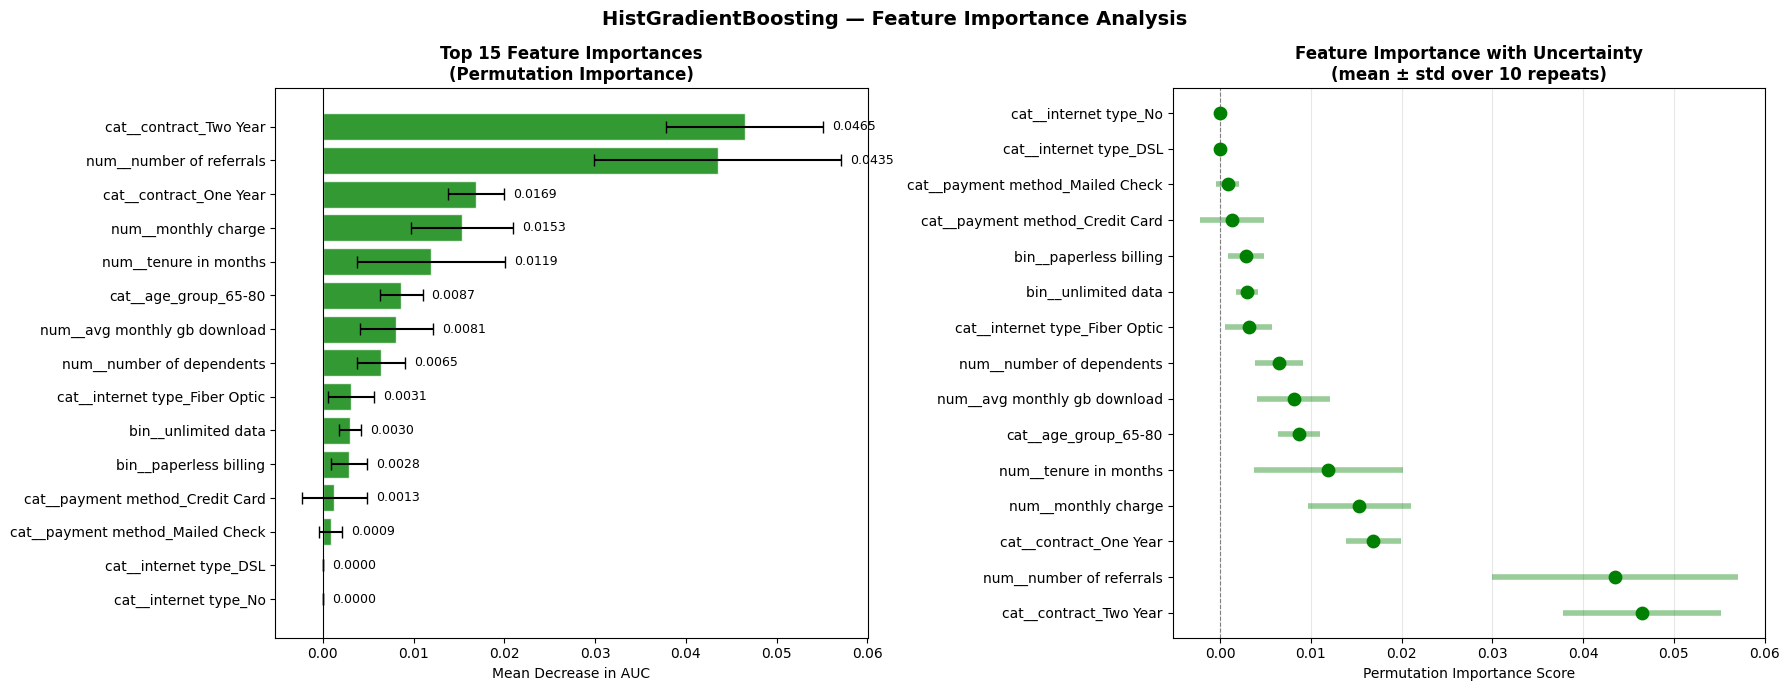


Top 10 Most Important Features:
                       feature  importance      std
        cat__contract_Two Year    0.046487 0.008665
      num__number of referrals    0.043506 0.013571
        cat__contract_One Year    0.016891 0.003058
           num__monthly charge    0.015330 0.005644
         num__tenure in months    0.011923 0.008171
          cat__age_group_65-80    0.008659 0.002328
  num__avg monthly gb download    0.008091 0.004005
     num__number of dependents    0.006458 0.002645
cat__internet type_Fiber Optic    0.003123 0.002543
           bin__unlimited data    0.002981 0.001221


In [13]:
from sklearn.inspection import permutation_importance
from matplotlib import gridspec

# ── Permutation importance ────────────────────────────────────────────────────
X_test_transformed = best_hgb.named_steps["preprocessor"].transform(X_test)
feature_names = best_hgb.named_steps["preprocessor"].get_feature_names_out()

perm_imp = permutation_importance(
    best_hgb.named_steps["classifier"],
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feat_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": perm_imp.importances_mean,
        "std": perm_imp.importances_std
    })
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left — horizontal bar chart with error bars
ax = axes[0]
bars = ax.barh(
    feat_df["feature"][::-1],
    feat_df["importance"][::-1],
    xerr=feat_df["std"][::-1],
    color="green", alpha=0.8, capsize=4, edgecolor="white"
)
ax.set_title("Top 15 Feature Importances\n(Permutation Importance)", fontweight="bold", fontsize=12)
ax.set_xlabel("Mean Decrease in AUC")
ax.axvline(0, color="black", linewidth=0.8)
for i, (imp, std) in enumerate(zip(feat_df["importance"][::-1], feat_df["std"][::-1])):
    ax.text(imp + std + 0.001, i, f"{imp:.4f}", va="center", fontsize=9)

# Right — dot plot showing importance with std band
ax2 = axes[1]
y_pos = range(len(feat_df))
ax2.scatter(feat_df["importance"], y_pos, color="green", zorder=5, s=80)
ax2.hlines(y_pos,
           feat_df["importance"] - feat_df["std"],
           feat_df["importance"] + feat_df["std"],
           color="green", alpha=0.4, linewidth=4)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(feat_df["feature"])
ax2.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_title("Feature Importance with Uncertainty\n(mean ± std over 10 repeats)", fontweight="bold", fontsize=12)
ax2.set_xlabel("Permutation Importance Score")
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("HistGradientBoosting — Feature Importance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print top 10 as table
print("\nTop 10 Most Important Features:")
print(feat_df[["feature","importance","std"]].head(10).to_string(index=False))

## 4.4 Interpretation & Business Implications — HistGradientBoosting

### Model Performance
The HistGradientBoosting classifier is an ensemble method that builds trees sequentially, 
where each tree corrects the errors of the previous one. Unlike Logistic Regression, it 
captures non-linear relationships between features, making it well suited for complex 
customer behaviour patterns like churn.

We optimise for ROC-AUC across 5-fold cross-validation, achieving a CV AUC of 0.906 ± 0.007 
— the strongest and most consistent result across all three models tested.

### Key Drivers of Churn
Permutation importance measures how much the model's AUC drops when a feature's values are 
randomly shuffled — a larger drop means the feature is more critical to predictions.

**Top drivers identified:**
- `contract_Two Year` (0.0465): the single most important feature — two-year contract holders 
  churn at dramatically lower rates than month-to-month customers
- `number of referrals` (0.0435): highly engaged customers who refer others rarely churn; 
  social investment in the product creates strong loyalty
- `contract_One Year` (0.0169): even a one-year commitment significantly reduces churn risk 
  relative to month-to-month
- `monthly charge` (0.0153): higher bills increase churn risk, particularly for newer customers 
  who haven't yet built loyalty
- `tenure in months` (0.0119): longer-tenured customers are far more loyal; the early months 
  represent the highest-risk period
- `age group 65-80` (0.0087): older customers churn significantly less, likely due to lower 
  price sensitivity and higher switching costs
- `avg monthly GB download` (0.0081): heavier usage correlates with lower churn — engaged 
  users get more value from the service
- `number of dependents` (0.0065): family accounts are stickier, likely due to higher 
  switching complexity

### Business Recommendations

1. **Prioritise contract conversion**: moving month-to-month customers onto annual or two-year 
   contracts is the single highest-leverage retention intervention available. Incentives such 
   as discounts, free months, or device upgrades at renewal are well justified by the churn 
   reduction they deliver.

2. **Launch a structured referral programme**: customers who refer others are among the most 
   loyal in the dataset. A referral scheme (e.g. bill credits per successful referral) 
   simultaneously grows the customer base and deepens retention — a rare double benefit.

3. **Target high-charge, short-tenure customers proactively**: the combination of above-average 
   monthly charges and tenure under 12 months on a month-to-month contract represents the 
   highest-risk customer profile. Proactive outreach with a loyalty offer before they reach 
   a decision point can prevent churn before it happens.

4. **Focus on early onboarding**: the first few months are the most critical window. 
   Structured onboarding programmes and early check-ins can build the loyalty and usage 
   habits that significantly improve long-term retention.

5. **Segment by demographics**: younger, single, month-to-month customers with no referrals 
   and high bills are the priority retention target. Older customers and those with dependents 
   churn at much lower rates and can be deprioritised in retention spend.

______________________________________________________________________